# Notebook for experiments with skeletonization

Imports

In [98]:
from typing import List, Set
import numpy as np
import uuid
import networkx as nx
from rdp import rdp
import os
from cv2 import imread
from skimage.morphology import skeletonize
from ypstruct import structure
import gng
import matplotlib.pyplot as plt

Additional parameters:

In [131]:
epsilon = 6
binary_threshold = 160

RDP implementation:

In [132]:
def simplify_network(net, epsilon: float = 1.0) -> List[np.ndarray]:
    # Find endpoints and intersections
    degree = np.sum(net.C, axis=0)
    endpoints = set(np.where(degree == 1)[0])
    intersections = set(np.where(degree > 2)[0])
    
    simplified_segments = []
    visited_edges = set()
    
    def traverse_segment(start: int, current: int) -> tuple[List[np.ndarray], int]:
        segment = [net.w[start]]
        while current not in endpoints and current not in intersections:
            segment.append(net.w[current])
            neighbors = set(np.where(net.C[current] == 1)[0]) - {start}
            if not neighbors:
                break
            start, current = current, neighbors.pop()
        segment.append(net.w[current])
        return segment, current

    def process_node(node: int) -> None:
        neighbors = set(np.where(net.C[node] == 1)[0])
        for neighbor in neighbors:
            edge = tuple(sorted([node, neighbor])) # Sort to ensure consistent edge representation
            if edge not in visited_edges:
                visited_edges.add(edge)
                segment, end = traverse_segment(node, neighbor)
                if len(segment) > 2:
                    simplified_segment = rdp(np.array(segment), epsilon)
                    # Only add if endpoints are preserved
                    if np.array_equal(simplified_segment[0], segment[0]) and np.array_equal(simplified_segment[-1], segment[-1]):
                        simplified_segments.append(simplified_segment)
                else:
                    # Always keep segments of length 2 to maintain connectivity
                    simplified_segments.append(np.array(segment))
                if end != neighbor:
                    process_node(end)

    # Process all endpoints and intersections
    for node in endpoints.union(intersections):
        process_node(node)
    
    return simplified_segments

Simplified network to NetworkX graph:

In [133]:
def to_networkx(simplified_network: List[List[np.ndarray]]) -> nx.Graph:
    """
    Convert the simplified network to a NetworkX graph with labeled nodes and edge data.

    Args:
        simplified_network (List[List[np.ndarray]]): The simplified network as a list of segments,
            each segment is a list of points represented as numpy arrays.

    Returns:
        nx.Graph: A NetworkX graph with nodes labeled by coordinates and edges with endpoint data.
    """
    G = nx.Graph()
    for i, segment in enumerate(simplified_network):
        for j in range(len(segment) - 1):
            source_coord = tuple(segment[j])
            target_coord = tuple(segment[j + 1])
            print(f"Source: {source_coord}, Target: {target_coord}")
            
            # Create unique identifiers for source and target nodes
            source_id = hash(source_coord)
            target_id = hash(target_coord)

            # Add source node with attributes if not already present
            if source_id not in G:
                G.add_node(source_id, x=source_coord[0], y=source_coord[1], uuid=str(uuid.uuid4()))

            # Add target node with attributes if not already present
            if target_id not in G:
                G.add_node(target_id, x=target_coord[0], y=target_coord[1], uuid=str(uuid.uuid4()))

            # Calculate edge length
            length = np.linalg.norm(np.array(target_coord) - np.array(source_coord))

            # Add edge with segment ID and endpoint information
            G.add_edge(source_id, target_id, 
                        segment_id=i, 
                        uuid=str(uuid.uuid4()),
                        x1=source_coord[0],
                        y1=source_coord[1],
                        x2=target_coord[0],
                        y2=target_coord[1],
                        length=length)

    return G

Iterate over images in folder function

In [134]:
def iterate_over_images_in_folder(folder_path: str):
    for file in os.listdir(folder_path):
        if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif")):
            yield file


In [135]:
def binary_image(image_path: str):
    image = imread(image_path, 0)
    binary = image > binary_threshold
    return binary

In [136]:
def skeleton_image(image_path: str):
    binary = binary_image(image_path)
    skeleton = skeletonize(binary)
    return skeleton

In [137]:
def get_image_points(skeleton: np.ndarray):
    points = []
    h, w = skeleton.shape
    for y in range(h):
        for x in range(w):
            # Threshold the pixel
            if skeleton[y, x] > 0:
                points.append([x, y])

    return np.array(points)

In [138]:
from pydantic import BaseModel
from dataclasses import dataclass
from typing import Generator, Any, Tuple, Optional
import networkx as nx

class Vector(BaseModel):
    id: str
    x1: float
    y1: float
    x2: float
    y2: float
    length: float

@dataclass
class Point:
    x: float
    y: float
    id: str

    def __hash__(self):
        return hash(self.uuid)

class GraphTraversal:
    def __init__(self, graph: nx.Graph):
        self.graph = graph

    def dfs_traversal(self, start_node: Any) -> Generator[Tuple[Point, Optional[Vector]], None, None]:
        visited_edges = set()

        def find_edge(x1: float, y1: float, x2: float, y2: float) -> Optional[dict]:
            for _, _, edge_data in self.graph.edges(data=True):
                if ((edge_data['x1'] == x1 and edge_data['y1'] == y1 and edge_data['x2'] == x2 and edge_data['y2'] == y2) or
                    (edge_data['x1'] == x2 and edge_data['y1'] == y2 and edge_data['x2'] == x1 and edge_data['y2'] == y1)):
                    return edge_data
            return None

        def _dfs(node_id: str, prev_x: Optional[float] = None, prev_y: Optional[float] = None):
            node_data = self.graph.nodes[node_id]
            point = Point(id=node_data["uuid"], x=node_data['x'], y=node_data['y'])
            
            incoming_vector = None
            if prev_x is not None and prev_y is not None:
                edge_data = find_edge(prev_x, prev_y, point.x, point.y)
                if edge_data:
                    incoming_vector = Vector(
                        id=edge_data['uuid'],
                        x1=prev_x,
                        y1=prev_y,
                        x2=point.x,
                        y2=point.y,
                        length=edge_data['length']
                    )
                else:
                    raise ValueError(f"Edge not found between {prev_x}, {prev_y} and {point.x}, {point.y}")
            
            yield point, incoming_vector

            for neighbor_id in self.graph.neighbors(node_id):
                edge = tuple(sorted([node_id, neighbor_id]))
                if edge not in visited_edges:
                    visited_edges.add(edge)
                    yield from _dfs(neighbor_id, point.x, point.y)

        yield from _dfs(start_node)

In [139]:
params = structure()
params.N = 50 # Number of neuronsq
params.maxit = 100 # Maximum number of iterations
params.L = 100 # Learning rate
params.epsilon_b = 0.2 # Basal lr
params.epsilon_n = 0.01 # Neighborhood lr
params.alpha = 0.5 # Learning rate decay
params.delta = 0.995 # Neighborhood radius decay
params.T = 50 # Number of epochs
    
def gng_process(image_points: np.ndarray):
    return gng.fit(image_points, params)

In [140]:
from typing import Tuple, Optional

def plot_graph_traversal(ax: plt.Axes, G: nx.Graph, traversal: List[Tuple[Point, Optional[Vector]]]):
    """
    Plot the graph traversal with arrows on the given axes.

    Args:
        ax (plt.Axes): The matplotlib axes to plot on.
        G (nx.Graph): The NetworkX graph.
        traversal (List[Tuple[Point, Optional[Vector]]]): The traversal result.
    """
    # Plot all edges in light gray
    # Plot all edges in light gray
    pos = {node: (G.nodes[node]['x'], G.nodes[node]['y']) for node in G.nodes()}
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray', arrows=False)

    # Plot nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color='lightblue')

    # Plot traversal with arrows
    for i, (point, vector) in enumerate(traversal):
        if vector:
            print(f"Vector {i}: x1: {vector.x1}, y1: {vector.y1}, x2: {vector.x2}, y2: {vector.y2}")
            ax.arrow(vector.x1, vector.y1, vector.x2 - vector.x1, vector.y2 - vector.y1,  # Swap x and y
                     head_width=3, head_length=3, fc='r', ec='r', 
                     length_includes_head=True, alpha=0.5)
        
        # Add numbers to show traversal order
        ax.text(point.x, point.y, str(i), fontsize=8, ha='center', va='center')

    ax.set_title('Graph Traversal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.invert_yaxis()  # Invert y-axis to match image coordinates

def plot_network_result(image_path, network, network_params: structure, points: np.ndarray, image: np.ndarray, binary: np.ndarray, skeleton: np.ndarray, simplified_network: List[List[np.ndarray]]):
    # Create a figure with four subplots side by side
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(40, 10))

    # Plot original image on the left
    ax1.imshow(image, cmap='gray')
    ax1.set_title(f'Original Image: {image_path}')
    ax1.axis('off')
    
    ax2.imshow(binary, cmap='gray')
    ax2.set_title('Binary Image')
    ax2.axis('off')

    # Plot skeletonized image in the middle-left
    ax3.imshow(skeleton, cmap='gray')
    ax3.set_title('Skeletonized Image')
    ax3.axis('off')

    # Plot GNG result in the middle-right
    ax4.grid()
    ax4.scatter(points[:, 0], points[:, 1], s=2)
    for i in range(network_params.N):
        for j in range(i+1, network_params.N):
            if network.C[i, j] == 1:
                ax4.plot([network.w[i, 0], network.w[j, 0]], [network.w[i, 1], network.w[j, 1]], c='r')

    ax4.scatter(network.w[:, 0], network.w[:, 1], s=60, c='y', edgecolors='r')

    ax4.set_title('GNG')
    ax4.set_xlabel('x')
    ax4.set_ylabel('y')
    ax4.axis('equal')
    ax4.invert_yaxis()  # Invert y-axis to match image coordinates

    # Plot simplified network on the right
    ax5.grid()
    ax5.scatter(points[:, 0], points[:, 1], s=2, alpha=0.3)
    for segment in simplified_network:
        ax5.plot(segment[:, 0], segment[:, 1], 'r-', linewidth=2)

    ax5.set_title('Simplified Network')
    ax5.set_xlabel('x')
    ax5.set_ylabel('y')
    ax5.axis('equal')
    ax5.invert_yaxis()  # Invert y-axis to match image coordinates

    plt.tight_layout()
    plt.show()

In [141]:
def find_top_leftmost_point(graph: nx.Graph) -> Optional[Any]:
    """
    Finds the top-leftmost point in the graph based on x and y coordinates.
    If no nodes with degree 1 exist, returns the node with highest degree.

    Returns:
        Optional[Any]: The top-leftmost point node or None if the graph is empty.
    """
    if not graph.nodes:
        return None

    degree_one_nodes = [node for node in graph.nodes if graph.degree[node] == 1]
    
    if degree_one_nodes:
        return min(
            degree_one_nodes,
            key=lambda n: (graph.nodes[n]["x"], 2 * graph.nodes[n]["y"]),
        )
    else:
        # Find node with maximum degree
        return max(graph.nodes, key=lambda n: graph.degree[n])

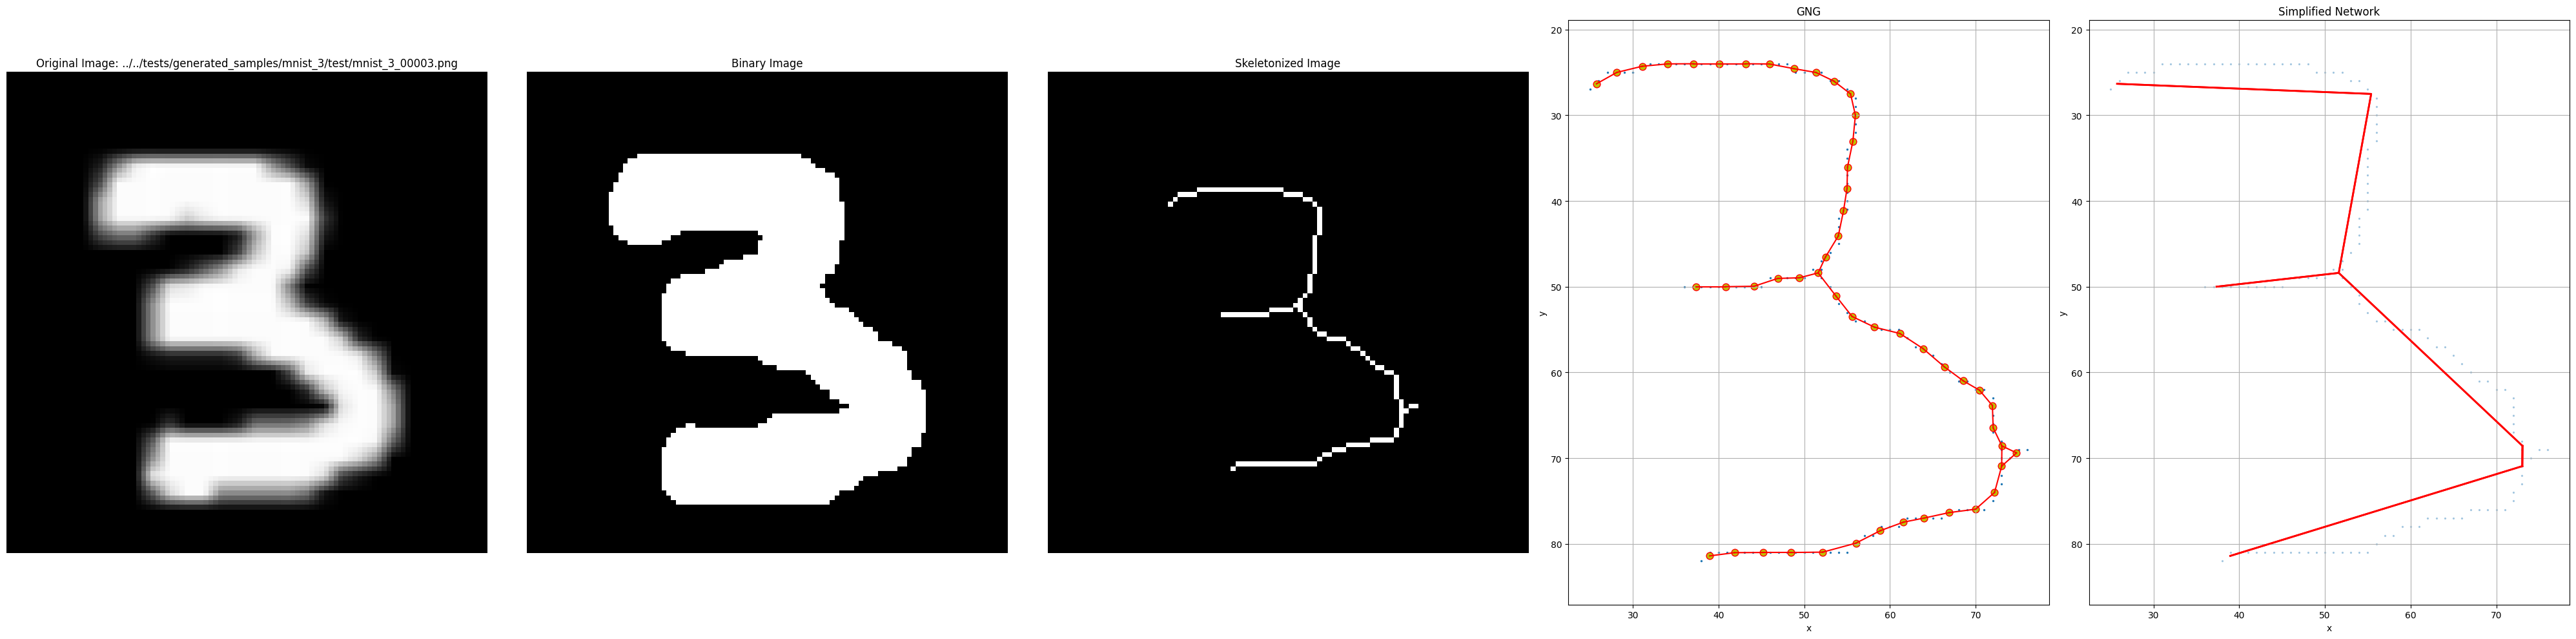

Source: (38.950019637250136, 81.39745082038937), Target: (73.03543998461903, 70.93076384336993)
Source: (73.03543998461903, 70.93076384336993), Target: (73.05842161288966, 68.57013186195643)
Source: (73.03543998461903, 70.93076384336993), Target: (73.05842161288966, 68.57013186195643)
Source: (73.05842161288966, 68.57013186195643), Target: (51.61423078139698, 48.393054147506085)
Source: (51.61423078139698, 48.393054147506085), Target: (55.39622908811275, 27.516724232939023)
Source: (55.39622908811275, 27.516724232939023), Target: (25.74220366058146, 26.336422515328398)
Source: (25.74220366058146, 26.336422515328398), Target: (55.39622908811275, 27.516724232939023)
Source: (55.39622908811275, 27.516724232939023), Target: (51.61423078139698, 48.393054147506085)
Source: (51.61423078139698, 48.393054147506085), Target: (73.05842161288966, 68.57013186195643)
Source: (73.05842161288966, 68.57013186195643), Target: (73.03543998461903, 70.93076384336993)
Source: (73.03543998461903, 70.93076384

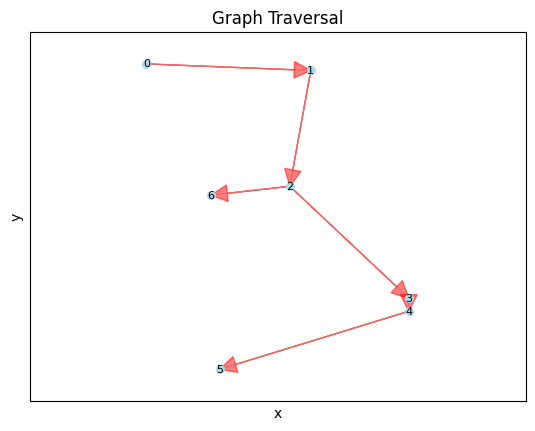

In [160]:
binary_threshold = 50

# Get 10 random images from the folder
# folder_path = '../../tests/prepared_samples/1_1'
folder_path = '../../tests/generated_samples/mnist_1/test'
images = [os.path.join(folder_path, file) for file in sorted(os.listdir(folder_path)) if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif"))]
# random_images = np.random.choice(images, len(images), replace=False)

images = ['../../tests/generated_samples/mnist_3/test/mnist_3_00003.png']

for image_path in images:
    image = imread(image_path, 0)
    binary = binary_image(image_path)
    skeleton = skeleton_image(image_path)
    image_points = get_image_points(skeleton)
    network = gng_process(image_points)
    simplified_network = simplify_network(network, epsilon=epsilon)
    plot_network_result(image_path, network, params, image_points, image, binary, skeleton, simplified_network)
    
    G = to_networkx(simplified_network)
    cycles = list(nx.simple_cycles(G))
    print(f"Cycles: {len(cycles)}")
    if not nx.is_connected(G):
        print(f"Graph {image_path} is not connected")
        continue
    top_leftmost_point = find_top_leftmost_point(G)
    print(f"Top leftmost point: {G.nodes[top_leftmost_point]}")    
    traversal = GraphTraversal(G).dfs_traversal(start_node=top_leftmost_point)
    
    plot_graph_traversal(plt.gca(), G, traversal)
    plt.show()

In [ ]:
def find_edge_by_uuid(self, uuid: str) -> Vector:
    for u, v, data in G.edges(data=True):
        if data['uuid'] == uuid:
            return u, v
    return None

line = find_edge_by_uuid(G, '63c31de3-7b67-428c-9e0b-12ed8100a155')
line_edge_data = G.edges[line]
print(f"Line: {line}. Data: {line_edge_data}")
neighbors = [edge for edge in set(G.edges(line[0])) | set(G.edges(line[1])) if edge[0] == line[0] or edge[1] == line[0]]
neighbors_edge_data = [G.edges[edge] for edge in neighbors]
print(f"Neighbors: {neighbors}. Data: {neighbors_edge_data}")
previous_line = [edge for edge in neighbors_edge_data if edge['x1'] == line_edge_data['x2'] and edge['y1'] == line_edge_data['y2']]
print(f"Previous line: {previous_line}")